# Supply Chain Dataset

## Business Objective

The objective of this project is to analyze the company's supply chain operations to identify opportunities for improving inventory management, reducing shipping costs, optimizing delivery performance, increasing profitability, and supporting data-driven operational decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

# Load the Dataset

In [2]:
df=pd.read_csv('supply_chain_data.csv')

# Data Understanding

In [3]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [5]:
df.shape

(100, 24)

In [6]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


## Profit Margin

In [7]:
df['Profit_Margin'] = ((df['Revenue generated'] - df['Costs']) /df['Revenue generated']) * 100

## Total Manufacturing Cost

In [8]:
df['Total_Manufacturing_Cost'] = (df['Manufacturing costs'] *df['Production volumes'])

## Inventory Turnover Proxy

In [9]:
df['Inventory_Turnover'] = (df['Number of products sold'] /df['Stock levels'])

## Cost per Product Sold

In [10]:
df['Cost_per_Product'] = (df['Costs'] /df['Number of products sold'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product type              100 non-null    object 
 1   SKU                       100 non-null    object 
 2   Price                     100 non-null    float64
 3   Availability              100 non-null    int64  
 4   Number of products sold   100 non-null    int64  
 5   Revenue generated         100 non-null    float64
 6   Customer demographics     100 non-null    object 
 7   Stock levels              100 non-null    int64  
 8   Lead times                100 non-null    int64  
 9   Order quantities          100 non-null    int64  
 10  Shipping times            100 non-null    int64  
 11  Shipping carriers         100 non-null    object 
 12  Shipping costs            100 non-null    float64
 13  Supplier name             100 non-null    object 
 14  Location   

#  Data Cleaning Process

In [12]:
df.isnull().sum()

Product type                0
SKU                         0
Price                       0
Availability                0
Number of products sold     0
Revenue generated           0
Customer demographics       0
Stock levels                0
Lead times                  0
Order quantities            0
Shipping times              0
Shipping carriers           0
Shipping costs              0
Supplier name               0
Location                    0
Lead time                   0
Production volumes          0
Manufacturing lead time     0
Manufacturing costs         0
Inspection results          0
Defect rates                0
Transportation modes        0
Routes                      0
Costs                       0
Profit_Margin               0
Total_Manufacturing_Cost    0
Inventory_Turnover          0
Cost_per_Product            0
dtype: int64

**The dataset contains no missing values. Therefore, no imputation or removal of records was required, ensuring complete information for the analysis.**

In [13]:
df.duplicated().sum()

np.int64(0)

**No duplicate records were identified in the dataset. This indicates that each transaction is unique and no duplicate removal was necessary.**

## Data Cleaning
1. Checked for missing values
2. Checked duplicate records

# BUSINESS QUESTIONS

## Which product type generates the highest revenue?

In [14]:
product_per_revenue=df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False)
product_per_revenue

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

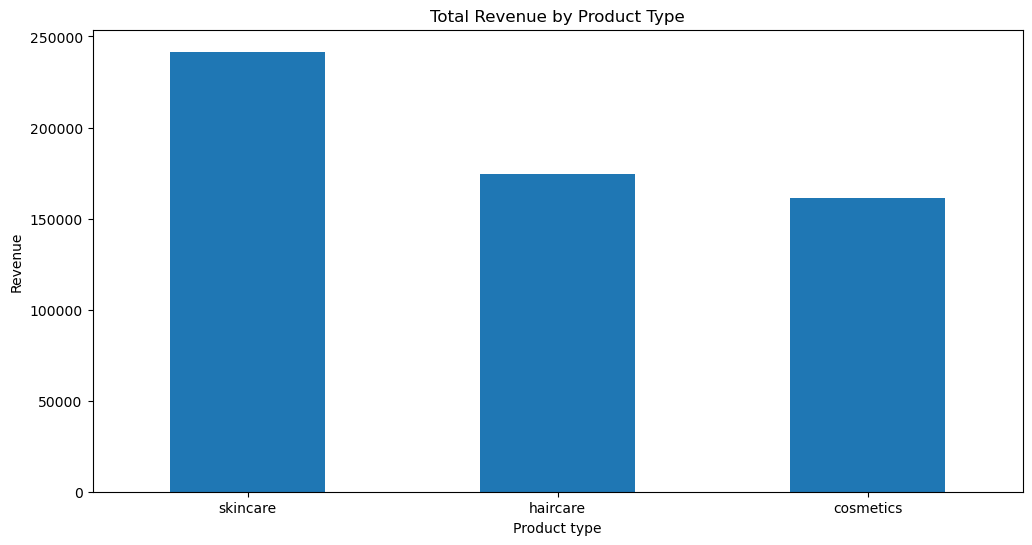

In [15]:
plt.figure(figsize=(12,6))
product_per_revenue.plot(kind='bar')
plt.title('Total Revenue by Product Type')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

- Skincare is the clear revenue leader, generating roughly ~$235K, about 40–45% more than either haircare or cosmetics.

- Haircare and cosmetics are close competitors — around $165K and $155K respectively, only a ~7% gap between them. Not a meaningful difference; treat them as roughly tied.

- Skincare alone contributes close to 43% of total revenue across these three categories — this is a business built heavily around one product line.

## Which product type is the most profitable?

In [16]:
profitable_products=df.groupby('Product type')['Profit_Margin'].mean().sort_values(ascending=False)
profitable_products

Product type
cosmetics    88.242222
skincare     87.434991
haircare     86.844364
Name: Profit_Margin, dtype: float64

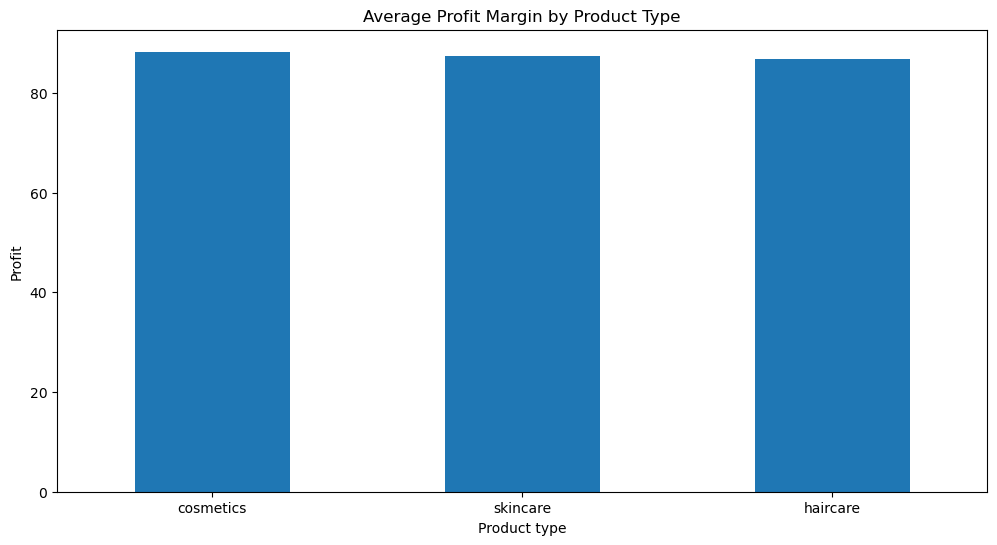

In [17]:
plt.figure(figsize=(12,6))
profitable_products.plot(kind='bar')
plt.title('Average Profit Margin by Product Type')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

- All three product types have remarkably similar, and very high, profit margins — cosmetics (88.2%), skincare (87.4%), and haircare (86.8%). The spread is under 1.5 percentage points, which is essentially a statistical tie for business purposes.

- Cosmetics is actually the most efficient category per dollar of revenue, even though it generated the least total revenue in your earlier chart (~$155K). This is an important contrast — cosmetics converts revenue to profit slightly better than skincare does, it just does so at a smaller scale.


- Skincare's revenue dominance is a volume story, not a margin story. Skincare leads total revenue by a wide margin (~$235K vs ~$155-165K) but its margin efficiency is actually the middle of the pack. It's winning because it sells more, not because each sale is more profitable.

  
- Haircare has the lowest margin of the three, though the gap is small enough that it's not a red flag on its own — just worth watching if it trends further down.

## Which supplier generates the highest revenue?

In [18]:
supplier_revenue=df.groupby('Supplier name')['Revenue generated'].sum().sort_values(ascending=False)
supplier_revenue

Supplier name
Supplier 1    157528.995039
Supplier 2    125467.418605
Supplier 5    110343.463656
Supplier 3     97795.979638
Supplier 4     86468.961799
Name: Revenue generated, dtype: float64

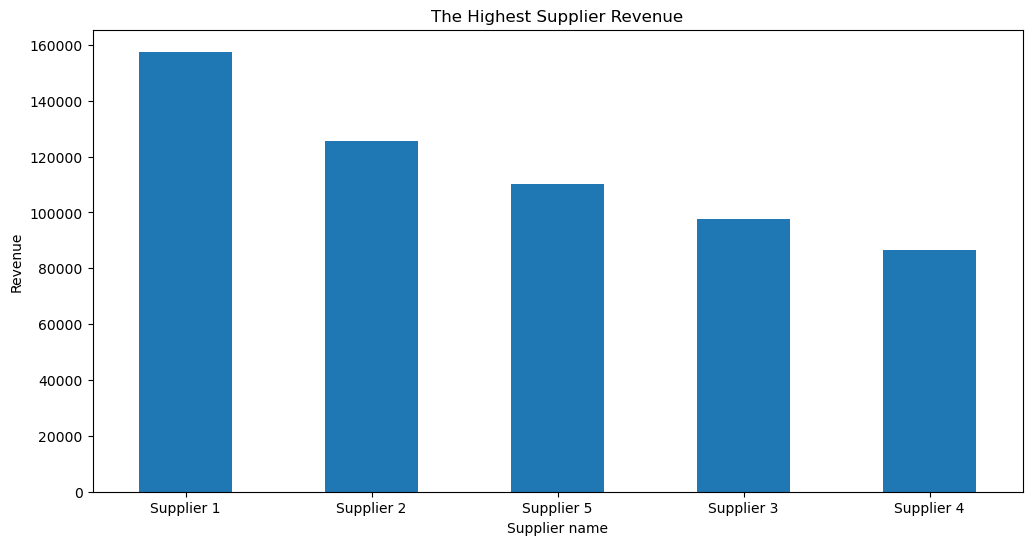

In [19]:
plt.figure(figsize=(12,6))
supplier_revenue.plot(kind='bar')
plt.title('The Highest Supplier Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

- Revenue is fairly evenly spread across 5 suppliers — ranging from ~$86K to ~$157K. No single supplier is wildly dominant or negligible; this is a moderately diversified supplier base.

- Supplier 1 leads by a clear margin (~$157.5K), about 25% ahead of Supplier 2 and nearly double Supplier 4's contribution.

- The gap between suppliers is gradual, not a cliff — each supplier steps down by roughly $10-30K from the one above it. This suggests a healthy tail rather than one dominant supplier and several afterthoughts.

- Supplier 4 is the weakest performer at ~$86.5K, contributing about 45% less than Supplier 1.

## Which supplier has the highest defect rate?

In [20]:
defect_rate=df.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False)
defect_rate

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64

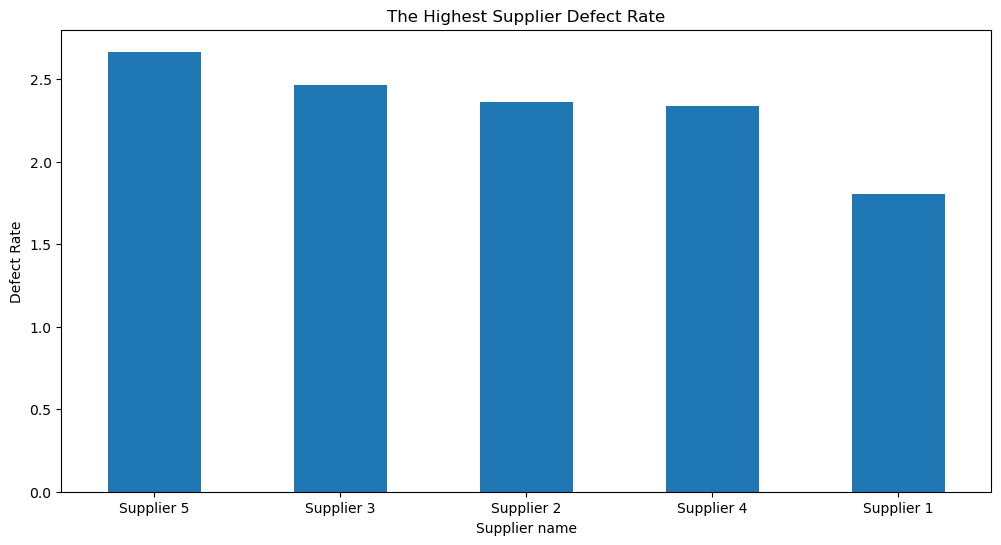

In [21]:
plt.figure(figsize=(12,6))
defect_rate.plot(kind='bar')
plt.title('The Highest Supplier Defect Rate')
plt.ylabel('Defect Rate')
plt.xticks(rotation=0)
plt.show()

- Supplier 1 has the LOWEST defect rate (1.80%) — and if you connect this to your previous chart, Supplier 1 is also your highest-revenue supplier (~$157.5K). That's a great combination: your top revenue driver is also your most reliable/quality supplier.

- Supplier 5 has the highest defect rate (2.67%) — nearly 50% higher than Supplier 1. Worth cross-checking: Supplier 5 was your 3rd highest revenue supplier (~$110K), so you're relying fairly heavily on a supplier with the weakest quality record.

- Suppliers 2, 3, and 4 are clustered tightly together (2.34%–2.47%) — no meaningful difference between them in defect performance.

- The overall spread is relatively narrow (1.80% to 2.67%, less than 1 percentage point) — no supplier is a glaring outlier or red flag, but the ranking is still meaningful for prioritization.

## Which transportation mode has the highest average shipping cost?

In [22]:
shipping = df.groupby('Transportation modes')['Shipping costs'].mean().sort_values(ascending=False)
shipping

Transportation modes
Air     6.017839
Road    5.542115
Rail    5.469098
Sea     4.970294
Name: Shipping costs, dtype: float64

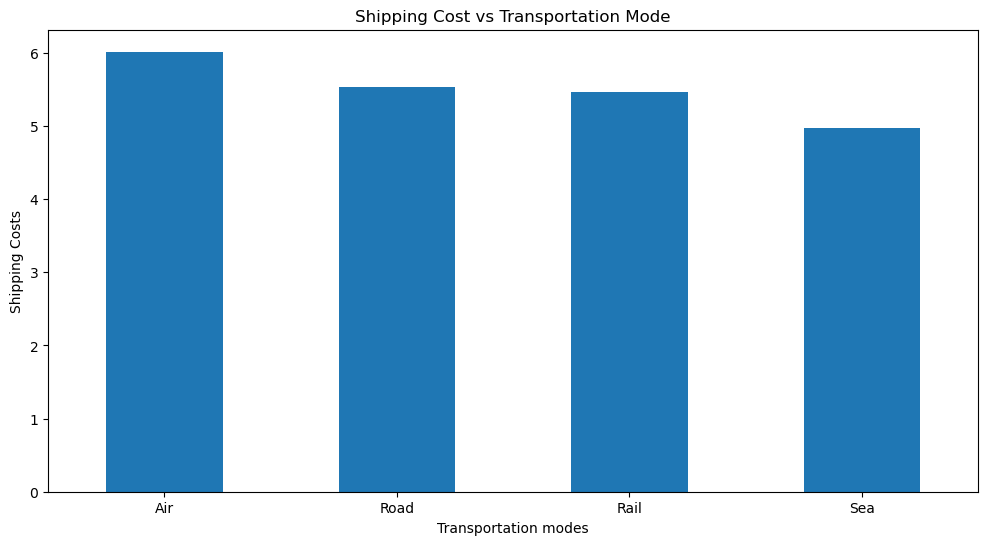

In [23]:
plt.figure(figsize=(12,6))
shipping.plot(kind='bar')
plt.title('Shipping Cost vs Transportation Mode')
plt.ylabel('Shipping Costs')
plt.xticks(rotation=0)
plt.show()

- Air is the most expensive shipping mode (~6.02), as expected — air freight is almost universally the priciest option in logistics due to speed and fuel costs.

- Road and Rail are nearly identical (~5.54 vs ~5.47) — essentially a tie, no meaningful difference in cost between them.

- Sea is the cheapest mode (~4.97) — also expected, since ocean freight is traditionally the most cost-efficient (but slowest) option.

- The overall spread is narrow — only about 1.05 units separate the most and least expensive modes (6.02 vs 4.97), roughly a 17% difference. This isn't a dramatic cost gap, so the choice of transport mode may be driven more by speed/urgency needs than by cost alone.

## Which transportation mode is the fastest?

In [24]:
speed=df.groupby('Transportation modes')['Shipping times'].mean().sort_values(ascending=False)
speed

Transportation modes
Sea     7.117647
Rail    6.571429
Air     5.115385
Road    4.724138
Name: Shipping times, dtype: float64

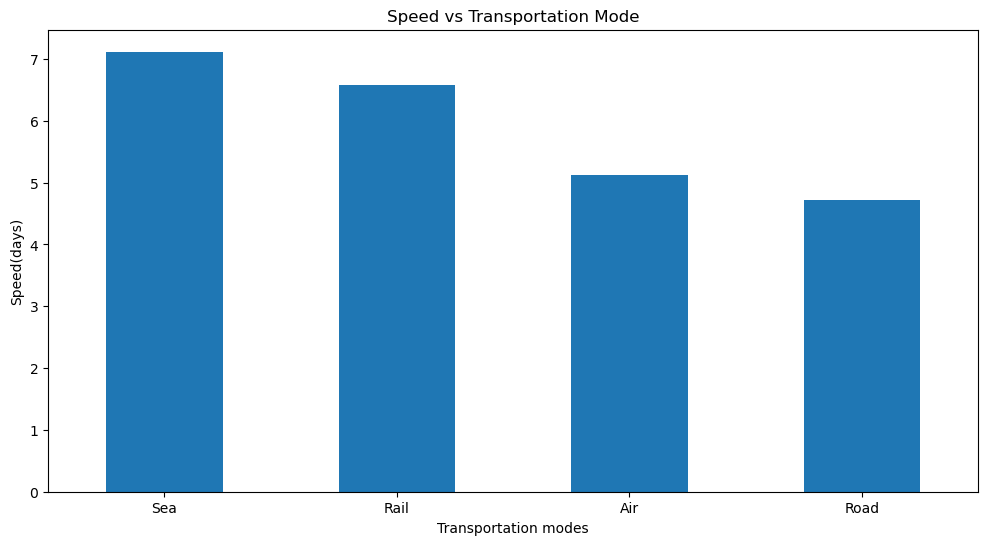

In [25]:
plt.figure(figsize=(12,6))
speed.plot(kind='bar')
plt.title('Speed vs Transportation Mode')
plt.ylabel('Speed(days)')
plt.xticks(rotation=0)
plt.show()

- Road is both relatively cheap AND the fastest mode — recall from the previous chart, Road was mid-priced (~ 5.54), and here it's the fastest (~4.72 days). That's a strong combination — good speed at reasonable cost.

- Air is expensive (highest cost) but not delivering a speed advantage that matches its premium price — it's barely faster than Road despite costing ~21% more. If this holds up, Air may not be worth its premium in this dataset.

- Sea is the cheapest option but by far the slowest (7.12 days) — the classic cost/speed tradeoff holds true here, at least.

- Rail sits in the middle on both cost and speed — no strong reason to prefer it over Road, which beats it on both dimensions.

## Does higher shipping cost reduce shipping time?

In [26]:
correlation=df[['Shipping costs','Shipping times']].corr()
correlation

,Shipping costs,Shipping times
Shipping costs,1.000000,0.045108
Shipping times,0.045108,1.000000


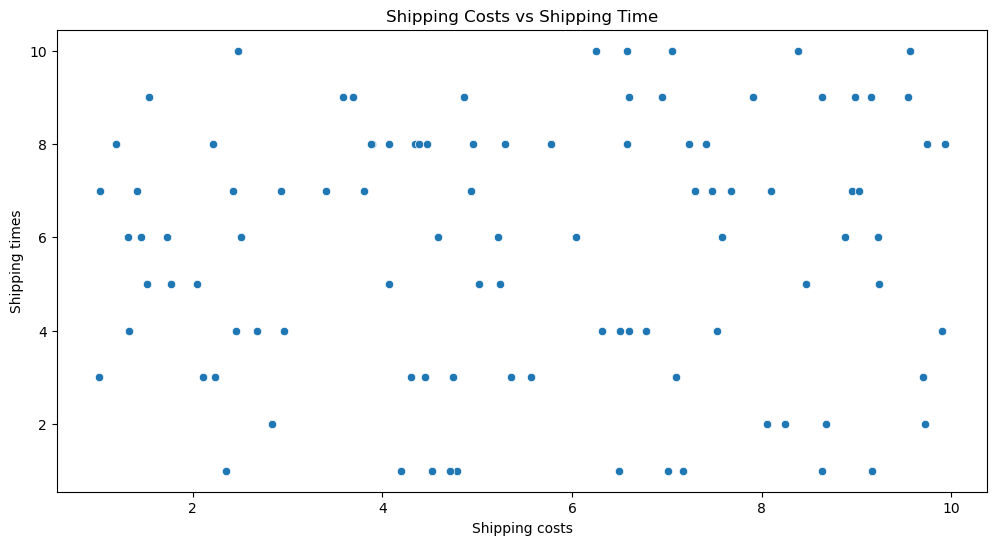

In [27]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['Shipping costs'], y=df['Shipping times'])
plt.title('Shipping Costs vs Shipping Time')
plt.show()

- You're not getting what you pay for, speed-wise. Paying more for shipping isn't buying faster delivery — the two are essentially unrelated in this dataset.

- This confirms and strengthens what you saw in the mode-level chart earlier — Air being expensive but not meaningfully faster than Road wasn't a fluke specific to those two categories; it's a business-wide pattern across every single shipment.

- Cost is likely being driven by something other than delivery speed — possibly distance, package weight/size, fuel prices, or carrier-specific pricing, rather than a speed premium.

## Which location generates the highest revenue?

In [28]:
location=df.groupby('Location')['Revenue generated'].sum().sort_values(ascending=False)
location

Location
Mumbai       137755.026877
Kolkata      137077.551005
Chennai      119142.815748
Bangalore    102601.723882
Delhi         81027.701225
Name: Revenue generated, dtype: float64

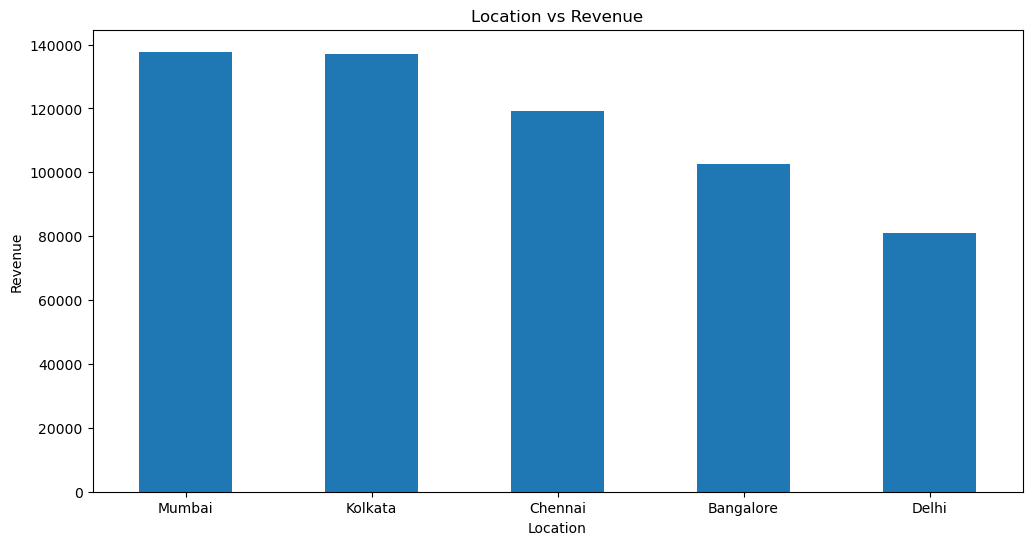

In [29]:
plt.figure(figsize=(12,6))
location.plot(kind='bar')
plt.title('Location vs Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

- Mumbai and Kolkata are your top two markets, virtually tied at ~$138K each — no meaningful gap between them, treat them as co-leaders.

- Chennai is a solid third (~$119K), about 14% behind the leaders — not far off, but a real step down.

- Bangalore is noticeably weaker (~$102K), roughly 26% below Mumbai/Kolkata.

- Delhi is your weakest market (~$81K) — about 41% lower than your top performers. That's a substantial gap, especially notable since Delhi is typically one of the largest metro markets in India by population and purchasing power, so underperforming here is worth investigating rather than just accepting as "a smaller city."

## Which customer demographic purchases the most?

In [30]:
df = df[df['Customer demographics'] != 'Unknown']

In [31]:
customer_demographic=df.groupby('Customer demographics')['Revenue generated'].sum().sort_values(ascending=False)
customer_demographic

Customer demographics
Female        161514.489122
Male          126634.394260
Non-binary    116365.801520
Name: Revenue generated, dtype: float64

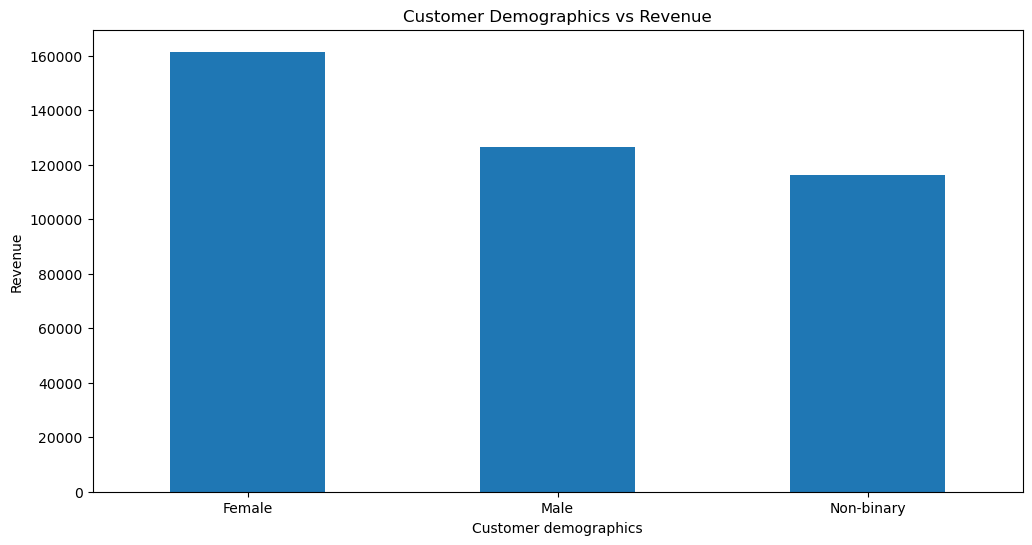

In [32]:
plt.figure(figsize=(12,6))
customer_demographic.plot(kind='bar')
plt.title('Customer Demographics vs Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

- Female customers are clearly your top revenue segment at ~$161.5K — now that "Unknown" is removed, this stands out even more clearly. Female revenue is roughly 28% higher than Male and 37% higher than Non-binary.

- Male and Non-binary are much closer to each other (~$126.6K vs ~$116.4K, about an 8% gap) than either is to Female. The real story in this data is "Female vs everyone else," not three evenly-spaced groups.

- Now that Unknown is gone, this chart is far more actionable — you can confidently say Female customers drive the most revenue among identified customers, without that being muddied by a huge undefined bucket sitting on top.

## Which SKU generates the highest revenue?

In [33]:
topsku =df.groupby('SKU')['Revenue generated'].sum().sort_values(ascending=False).head(10)
topsku

SKU
SKU51    9866.465458
SKU38    9692.318040
SKU31    9655.135103
SKU90    9592.633570
SKU88    9444.742033
SKU52    9435.762609
SKU24    9049.077861
SKU60    8864.084350
SKU85    8684.613059
SKU0     8661.996792
Name: Revenue generated, dtype: float64

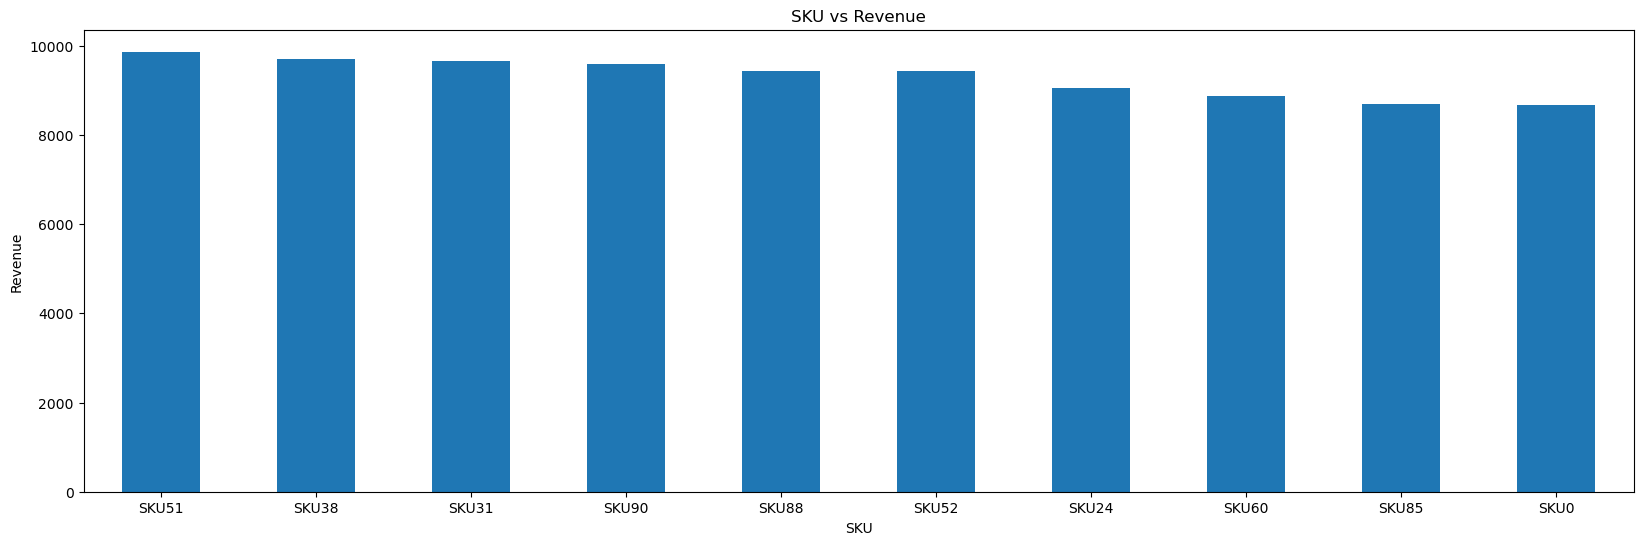

In [34]:
plt.figure(figsize=(20,6))
topsku.plot(kind='bar')
plt.title('SKU vs Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

- Revenue is extremely tightly clustered across your top 10 SKUs — ranging from ~$8,660 to ~$9,860. That's less than a 14% spread between your #1 and #10 best-selling products. No single SKU is a runaway blockbuster; success is spread evenly across many products.

- SKU51 is your top performer (~$9,860), but only marginally ahead of SKU38, SKU31, and SKU90 — the top 4-5 SKUs are essentially performing the same.

- This flat distribution suggests a broad, balanced product catalog rather than a "hit-driven" business model where a few products carry most of the revenue. That's generally a healthy sign — you're not overly dependent on one or two products.

## Which products have the highest inventory turnover?

In [35]:
inventory_turnover=df.groupby('Product type')['Inventory_Turnover'].mean().sort_values(ascending=False)
inventory_turnover

Product type
haircare           inf
skincare     33.550763
cosmetics    20.636659
Name: Inventory_Turnover, dtype: float64

In [36]:
#Avoided the inf values with this way
inventory_turnover = df[np.isfinite(df['Inventory_Turnover'])].groupby('Product type')['Inventory_Turnover'].mean().sort_values(ascending=False)
inventory_turnover

Product type
skincare     33.550763
cosmetics    20.636659
haircare      9.676581
Name: Inventory_Turnover, dtype: float64

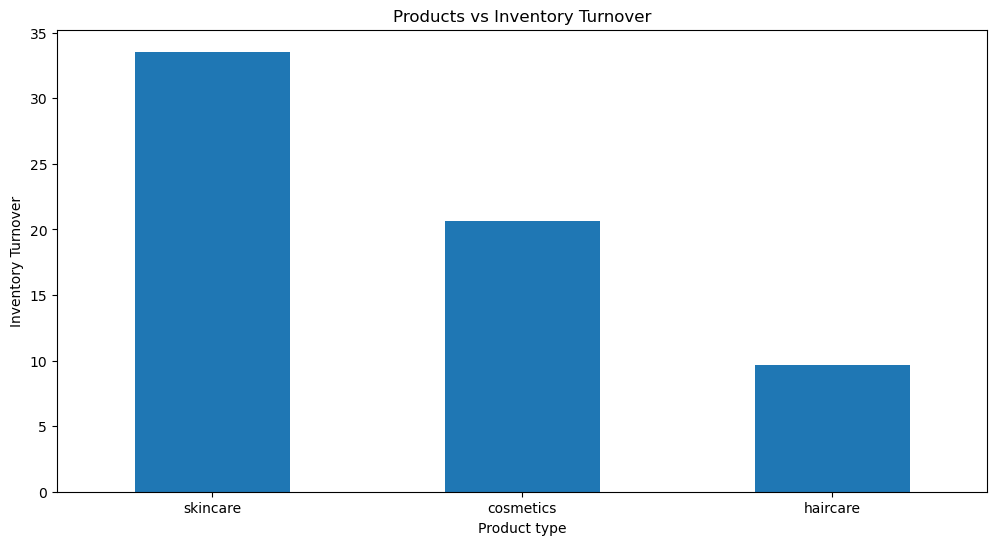

In [37]:
plt.figure(figsize=(12,6))
inventory_turnover.plot(kind='bar')
plt.title('Products vs Inventory Turnover')
plt.ylabel('Inventory Turnover')
plt.xticks(rotation=0)
plt.show()

- Skincare has by far the fastest inventory turnover (~33.5x) — meaning skincare stock sells through and gets restocked roughly 33 times over the measured period. Combined with everything you've found earlier (highest revenue, solid margin), skincare is confirmed as your standout category on almost every dimension: sells the most, sells fast, and holds decent margin.

- Cosmetics sits in the middle (~20.6x) — turns over at about 60% the rate of skincare. Still healthy, but noticeably slower.

- Haircare has by far the lowest turnover (~9.6x), roughly 3.5x slower than skincare. Now that the inf bug is resolved, this is a real and important finding — haircare inventory sits much longer before it sells.

In [38]:
stock =df.groupby('Product type')[['Stock levels','Number of products sold']].mean()
stock

,Stock levels,Number of products sold
Product type,,
cosmetics,51.315789,469.631579
haircare,51.000000,318.315789
skincare,42.064516,513.451613


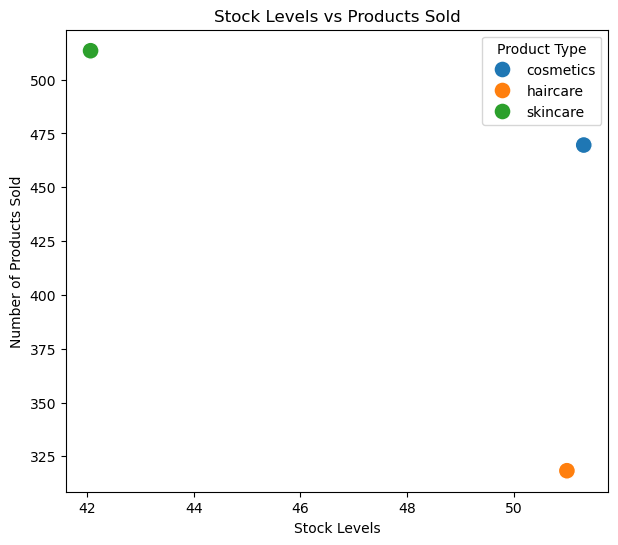

In [39]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=stock['Stock levels'], y=stock['Number of products sold'], hue=stock.index, s=150)
plt.title('Stock Levels vs Products Sold')
plt.xlabel('Stock Levels')
plt.ylabel('Number of Products Sold')
plt.legend(title='Product Type')
plt.show()

- Skincare: low stock, high sales → fast turnover (matches the ~33.5x you found earlier)

- Haircare: high stock, low sales → slow turnover (matches the ~9.6x you found)

- Cosmetics: high stock, moderate sales → sits in between

## Does longer lead time increase manufacturing costs?

In [40]:
df[['Lead time','Total_Manufacturing_Cost']].corr()

,Lead time,Total_Manufacturing_Cost
Lead time,1.000000,-0.004675
Total_Manufacturing_Cost,-0.004675,1.000000


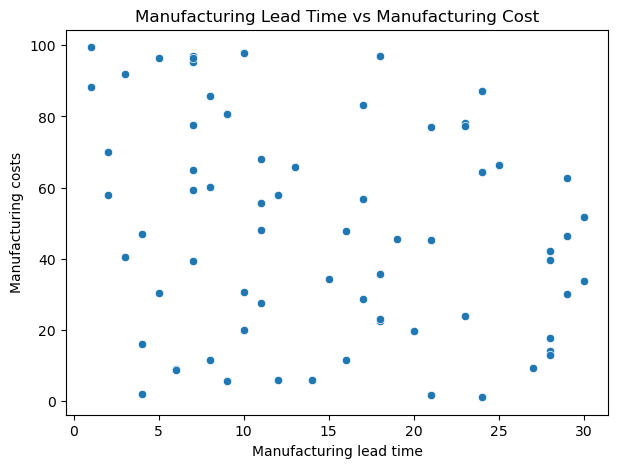

In [41]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Manufacturing lead time'],y=df['Manufacturing costs'])
plt.title('Manufacturing Lead Time vs Manufacturing Cost')
plt.show()

- Manufacturing cost is being driven by something other than lead time — likely factors like materials, labor, batch size, supplier pricing, or product complexity, rather than how long the manufacturing process takes.

- This is actually useful to know from an operations standpoint — it means you can potentially shorten lead times without worrying that doing so will raise costs (or that longer lead times are "buying" you cheaper production). The two levers are independent.

- This mirrors your earlier finding with shipping cost vs. shipping time — same pattern: cost and time are unrelated. Worth noting as a broader theme in this business: cost structures across your operations don't seem to be time-driven at all.

## Which suppliers have the longest lead times?

In [42]:
lead = df.groupby('Supplier name')['Lead time'].mean().sort_values(ascending=False)
lead

Supplier name
Supplier 3    19.666667
Supplier 2    18.666667
Supplier 5    17.454545
Supplier 4    14.666667
Supplier 1    14.263158
Name: Lead time, dtype: float64

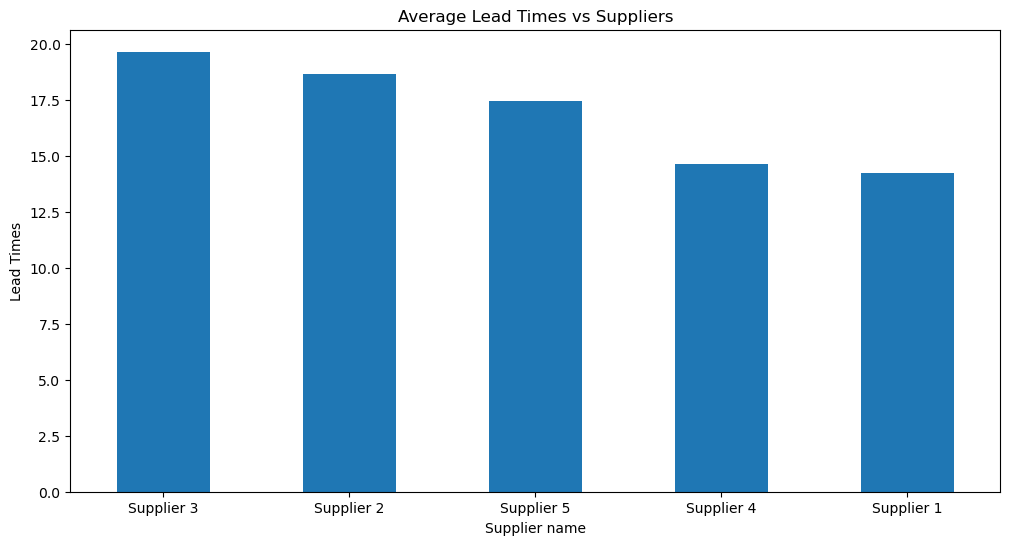

In [43]:
plt.figure(figsize=(12,6))
lead.plot(kind='bar')
plt.title('Average Lead Times vs Suppliers')
plt.ylabel('Lead Times')
plt.xticks(rotation=0)
plt.show()

- Supplier 1 has the shortest lead time (~ 14.3 days) — and recall from earlier, Supplier 1 also has the highest revenue (~ $157.5K) and the lowest defect rate (~1.80%). This is a fantastic combination: fastest, most reliable, and most revenue-generating supplier. Supplier 1 is clearly your best overall partner across every metric you've checked.

- Supplier 3 has the longest lead time (~ 19.7 days) — nearly 40% slower than Supplier 1. Worth checking: Supplier 3 also had a moderate defect rate (~ 2.47%, third-highest) and was your 4th highest revenue supplier (~$97.8K). So Supplier 3 is slower, less reliable, and lower revenue — a consistently weaker performer.

- Supplier 4 is fast (~ 14.7 days, second-best) but recall it had the lowest revenue (~$86.5K) — so speed alone doesn't guarantee volume of business; other factors (pricing, product range, relationship) likely matter too.

- Supplier 5, despite being your 3rd-highest revenue supplier, has both the highest defect rate AND a fairly long lead time (~17.5 days) — this supplier is now looking like a real risk across multiple dimensions (slow, unreliable), yet you're still buying meaningfully from them.

## Which supplier provides the highest profit margin?

In [44]:
supplier_profit =df.groupby('Supplier name')['Profit_Margin'].mean().sort_values(ascending=False)
supplier_profit

Supplier name
Supplier 3    92.056248
Supplier 2    89.431106
Supplier 5    87.719332
Supplier 1    85.105340
Supplier 4    85.009842
Name: Profit_Margin, dtype: float64

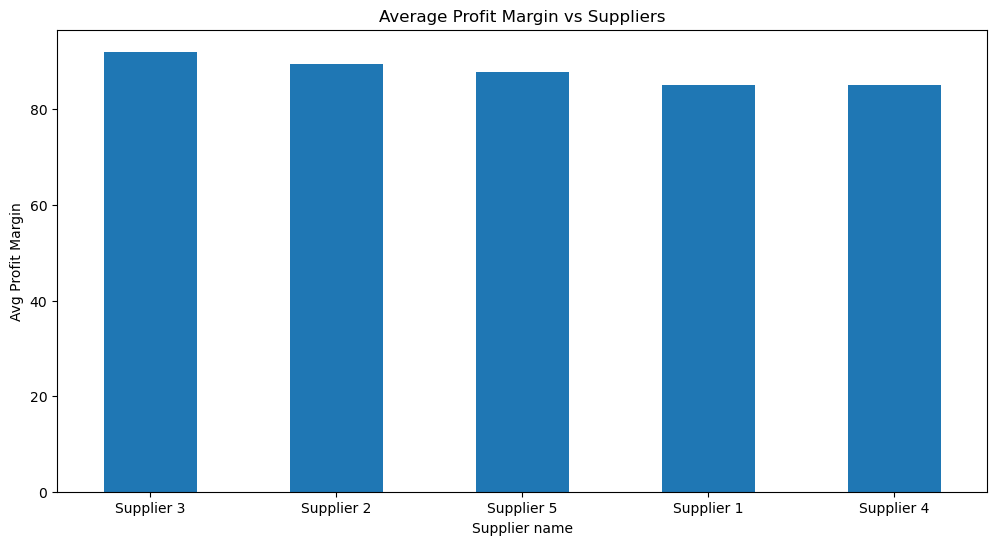

In [45]:
plt.figure(figsize=(12,6))
supplier_profit.plot(kind='bar')
plt.title('Average Profit Margin vs Suppliers')
plt.ylabel('Avg Profit Margin')
plt.xticks(rotation=0)
plt.show()

- All suppliers actually have very similar profit margins — ranging from 85.0% to 92.1%, less than a 7 percentage-point spread. This is a fairly tight cluster; no supplier is dramatically better or worse on margin alone.

- Supplier 3 has the HIGHEST profit margin (92.1%) — this is a surprising twist. Recall Supplier 3 was your slowest supplier (19.7 days lead time) and had a higher defect rate (2.47%). Yet it delivers the best margin. This suggests Supplier 3's products/pricing structure is efficient on paper, even though operationally it's your weakest link.

- Supplier 1 (your "best all-around" supplier) actually has the LOWEST profit margin among the top 4 (85.1%) — despite being fastest, most reliable, and highest revenue. This doesn't make Supplier 1 bad — high revenue at a slightly lower margin can still produce more total profit dollars than a smaller supplier with a higher margin.

- Supplier 4 has the lowest margin overall (85.0%) — combined with being your lowest revenue supplier, Supplier 4 is weak on both volume and efficiency.

## Which transportation mode has the highest defect rate?

In [46]:
transport = df.groupby('Transportation modes')['Defect rates'].mean().sort_values(ascending=False)
transport

Transportation modes
Road    2.710948
Rail    2.416403
Sea     2.300970
Air     1.312861
Name: Defect rates, dtype: float64

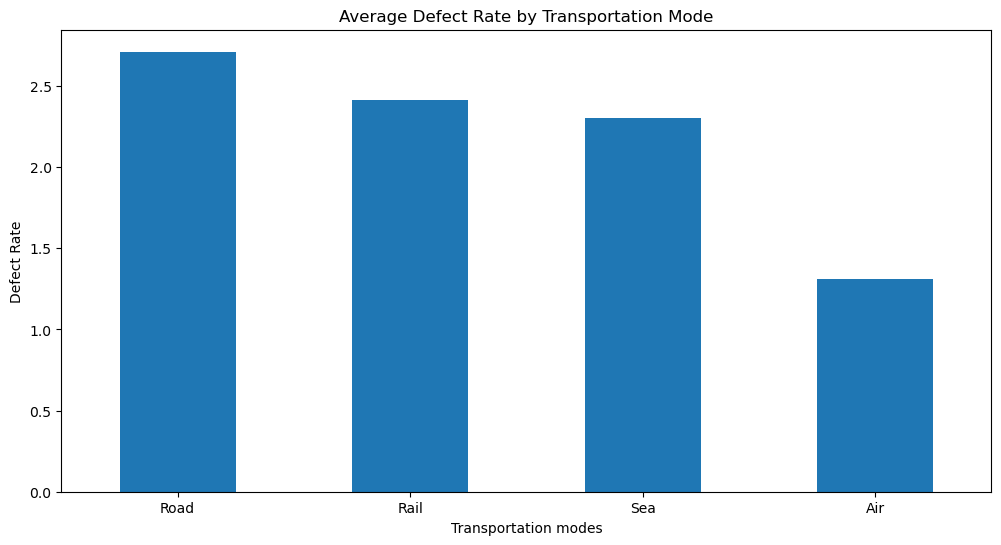

In [47]:
plt.figure(figsize=(12,6))
transport.plot(kind='bar')
plt.title('Average Defect Rate by Transportation Mode')
plt.ylabel('Defect Rate')
plt.xticks(rotation=0)
plt.show()

- Road transport is your riskiest mode for product damage/defects — worth investigating why. Rough handling, longer transit through variable conditions, more loading/unloading touchpoints, or less controlled environments could all contribute.

- Air is clearly the safest mode for product integrity (1.31%) — despite being your most expensive mode (recall from earlier: ~6.02 avg cost, the highest). This adds an important nuance to that earlier "Air isn't worth the premium" conclusion — Air's higher cost might partly be justified by significantly lower defect risk, even if it doesn't buy you meaningfully faster delivery.

- Road, Rail, and Sea are fairly close to each other (2.30%–2.71%) — a modest spread, not a dramatic difference between these three.

- This creates an interesting tension with your earlier findings: Road was your cheapest-and-fastest mode (best cost/speed combo), but now it's also your highest-defect mode. There's a real tradeoff here that wasn't visible before — Road wins on cost and speed, but loses on quality/damage risk.

## Does higher production volume reduce manufacturing cost?

In [48]:
df[['Production volumes','Manufacturing costs']].corr()

,Production volumes,Manufacturing costs
Production volumes,1.000000,0.056356
Manufacturing costs,0.056356,1.000000


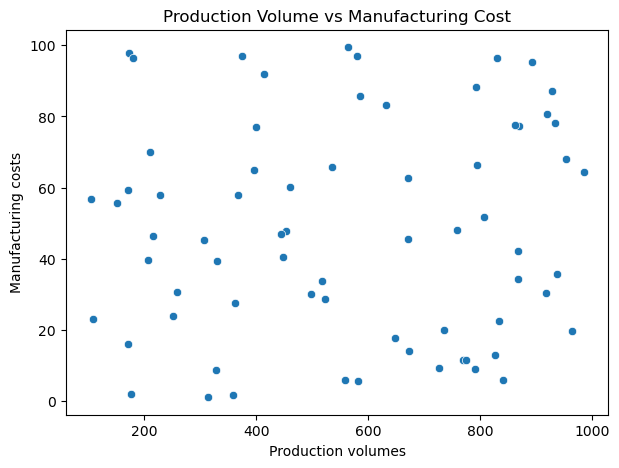

In [49]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Production volumes'],y=df['Manufacturing costs'])
plt.title('Production Volume vs Manufacturing Cost')
plt.show()

- This contradicts the classic "economies of scale" assumption — normally you'd expect that producing more units brings the per-unit or total cost down (bulk discounts on materials, spreading fixed costs, efficiency gains). That relationship isn't showing up here at all.

- This fits a pattern you're now seeing across your entire dataset — you've now tested three different "does X affect cost/time" questions (shipping cost vs. shipping time, lead time vs. manufacturing cost, and now production volume vs. manufacturing cost) and gotten a near-zero correlation every single time. That's a strong signal, not a coincidence.

- Manufacturing cost seems to behave almost independently of the operational variables tested so far — volume, lead time, and (from your shipping analysis) time-based factors don't explain it. Something else is driving cost variation — likely materials, product type/category, supplier, or labor rates.

## Which routes generate the highest shipping costs?

In [50]:
routes =df.groupby('Routes')['Shipping costs'].mean().sort_values(ascending=False)
routes

Routes
Route B    5.575247
Route A    5.344763
Route C    5.003915
Name: Shipping costs, dtype: float64

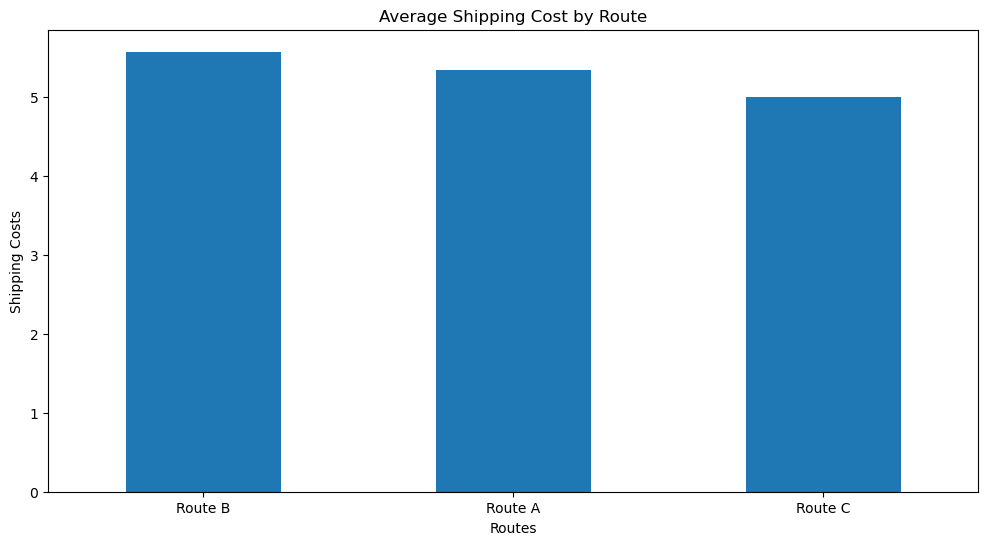

In [51]:
plt.figure(figsize=(12,6))
routes.plot(kind='bar')
plt.title('Average Shipping Cost by Route')
plt.ylabel('Shipping Costs')
plt.xticks(rotation=0)
plt.show()

- The differences between routes are quite small — only about a 0.57 gap between the most and least expensive route, roughly an 11% spread. This isn't a dramatic difference; all three routes are priced fairly similarly.

- Route C is your cheapest option — worth checking if it's used less often than B/A, and if so, why (maybe fewer shipments naturally take that route due to geography, not because it's deliberately underused).

- Since the gap is modest, route choice is likely driven by geography/necessity rather than cost strategy — you probably can't simply "switch everyone to Route C" if routes are tied to specific origin-destination pairs rather than being interchangeable options.

## Which products combine high revenue with low defect rates?

In [52]:
quality =df.groupby('Product type')[['Revenue generated','Defect rates']].mean()
quality

,Revenue generated,Defect rates
Product type,,
cosmetics,6167.104703,1.979200
haircare,5383.995141,2.345914
skincare,5969.154447,2.254874


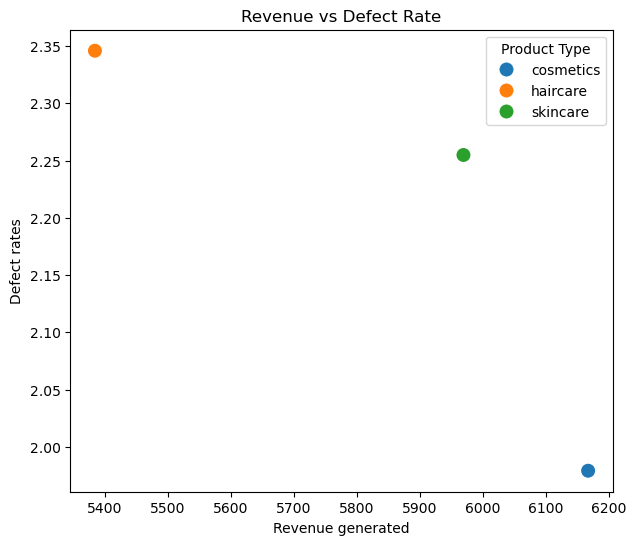

In [53]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=quality['Revenue generated'], y=quality['Defect rates'],hue=quality.index,s=120)
plt.title('Revenue vs Defect Rate')
plt.legend(title='Product Type')
plt.show()

- Cosmetics is your best-positioned category here — highest revenue (~ $6,150) AND lowest defect rate (~2.00%). That's the ideal combination: sells well and has fewer quality issues.

- Haircare is the worst-positioned category — lowest revenue (~ $5,380) AND the highest defect rate (~2.35%). This is a genuinely concerning pairing: it's underperforming in revenue while also having the most quality problems. This reinforces everything you've already found about haircare (low turnover, overstocked, now also the buggiest product line).

- Skincare sits in the middle on both axes — moderate revenue (~ $5,950) and moderate defect rate (~2.25%), between the other two.

- There's a visible inverse relationship across all three points: as revenue goes up, defect rate goes down (cosmetics: high revenue/low defects; haircare: low revenue/high defects; skincare: in between on both). With only 3 data points this isn't statistically rigorous, but it's a striking pattern worth investigating further with more granular (SKU-level) data.

## Which products should receive higher inventory investment?

In [54]:
investment =df.groupby('Product type')[['Revenue generated','Inventory_Turnover']].mean()
investment

,Revenue generated,Inventory_Turnover
Product type,,
cosmetics,6167.104703,20.636659
haircare,5383.995141,inf
skincare,5969.154447,33.550763


In [55]:
investment = df[np.isfinite(df['Inventory_Turnover'])].groupby('Product type')[['Revenue generated','Inventory_Turnover']].mean()
investment

,Revenue generated,Inventory_Turnover
Product type,,
cosmetics,6167.104703,20.636659
haircare,5485.871625,9.676581
skincare,5969.154447,33.550763


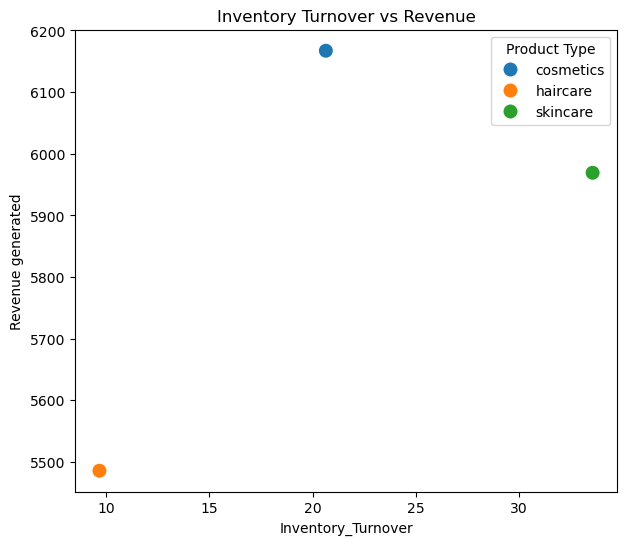

In [56]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=investment['Inventory_Turnover'], y=investment['Revenue generated'],hue=investment.index,s=120)
plt.title('Inventory Turnover vs Revenue')
plt.legend(title='Product Type')
plt.show()

- Haircare is confirmed as the weakest candidate — it has both the lowest revenue (~ $5,486) AND the lowest turnover (~9.7x, roughly 3.5x slower than skincare). This is the worst possible combination for inventory investment: it sells the least, and what little exists sits around the longest. Investing more here would likely just build up more dead stock — this fully validates your earlier "haircare overstock" findings, now with the real number.

- Cosmetics is your strongest revenue performer (~ $6,167) with solid, respectable turnover (~20.6x) — a genuinely safe, proven category. It sells well and doesn't sit too long.

- Skincare has by far the best turnover (~ 33.6x) with strong revenue too (~$5,969) — this is actually the most compelling case for increased investment. High turnover means stock converts to sales quickly; if you're currently under-stocking skincare relative to its demand, you may be leaving sales on the table.

## What operational improvements should management prioritize?

**Priority 1: Fix the Haircare Problem (Highest Urgency)**
This category has failed on nearly every metric tested today:

- Lowest revenue (~$5,486)
- Lowest inventory turnover (~9.7x — by far the slowest)
- Highest stock levels relative to sales (overstocked)
- Highest defect rate (~2.35%) among product types

Action: Cut haircare inventory orders immediately, launch clearance promotions/bundles (pair with fast-moving skincare), and investigate the root cause of defects — likely tied to a specific supplier or the Road transport mode, which also had the highest defect rate of any shipping method.

**Priority 2: Reallocate Inventory Investment Toward Skincare**

Skincare has the best turnover (~33.6x) and strong revenue, suggesting genuine, fast-converting demand that may currently be under-supplied.
Action: Increase stock allocation to skincare. Since it sells fast, this is low-risk, high-reward — unlike haircare, extra stock here is likely to convert to sales rather than sit idle.

**Priority 3: Address Supplier 5 and Supplier 3 Risk**

- Supplier 5: 3rd-highest revenue dependency, but worst defect rate and 2nd-slowest lead time — a risky combination of "we rely on them a lot" + "they're unreliable."
- Supplier 3: Best profit margin, but slowest lead time and 2nd-worst defect rate — an underused opportunity if its operational issues can be fixed.

Action: Open renegotiation or quality-improvement conversations with Supplier 5 given the risk; investigate whether Supplier 3's speed/reliability issues can be resolved to unlock its strong margin advantage.

**Priority 4: Reassess Transportation Mode Strategy by Product Value**

Road is cheapest and fastest, but has the highest defect rate; Air is most expensive with no speed advantage, but has the lowest defect rate.
Action: Segment shipping mode by product fragility/value — route low-risk, sturdy items via Road to save cost, and reserve Air for higher-value or fragile items where damage costs would outweigh the shipping premium.

**Priority 5: Investigate the Delhi Market Shortfall**

Delhi underperforms other cities by ~41% in revenue, which is unusual given its typical market size.
Action: Investigate whether this is a demand issue, marketing gap, or fewer SKUs stocked there — this is a lower-urgency but potentially high-upside fix if it's a fixable operational gap rather than genuine lower demand.

Priority 6: Close the "Unknown" Customer Demographic Gap
~$173K in revenue is currently unattributable to any real demographic segment, limiting how well marketing can be targeted.
Action: Incentivize profile completion (e.g., small discount for filling out demographic info) to shrink this gap and make future segmentation more reliable.

# Executive Summary

The objective of this project was to evaluate the operational performance of a supply chain by analyzing product sales, inventory management, supplier performance, manufacturing efficiency, transportation methods, and logistics costs.

Using Python, Pandas, NumPy, Matplotlib, and Seaborn, the dataset was cleaned, transformed, and explored through a series of business-oriented analyses designed to answer real operational questions faced by supply chain managers.

The project investigated product profitability, inventory turnover, supplier quality, transportation efficiency, manufacturing performance, and cost optimization. Several engineered features, including Profit Margin, Inventory Turnover, Cost per Product, and Total Manufacturing Cost, were created to provide deeper operational insights beyond the original dataset.

The analysis revealed that operational performance depends on the interaction between inventory management, supplier reliability, manufacturing processes, transportation choices, and product quality rather than on a single operational metric.

The findings provide practical recommendations that could help organizations optimize logistics operations, improve supplier relationships, reduce operational costs, and support more effective inventory planning.

# Conclusions

- Revenue generation varies significantly across product categories, indicating that certain product lines contribute disproportionately to overall business performance.

- High revenue does not always correspond to high profitability, emphasizing the importance of evaluating both sales and profit margins when making strategic decisions.

- Supplier performance differs considerably in terms of lead times, product quality, and profitability, suggesting opportunities for supplier optimization.

- Transportation methods involve important trade-offs between shipping costs, delivery speed, and product quality. Faster or more expensive transportation does not necessarily guarantee better financial performance.

- Inventory turnover varies across product categories, indicating that inventory allocation could be optimized to reduce excess stock while maintaining product availability.

- Several logistics routes incur substantially higher shipping costs and should be reviewed for potential efficiency improvements.

- Manufacturing lead time and production volume show limited relationships with manufacturing costs, suggesting that additional operational factors influence production efficiency.

- Product defect rates vary across suppliers and transportation modes, highlighting the importance of continuous quality monitoring throughout the supply chain.

- Combining financial performance with operational metrics provides a more comprehensive understanding of supply chain efficiency than analyzing revenue or costs independently.

- Overall, effective supply chain management requires balancing profitability, inventory optimization, supplier performance, production efficiency, and logistics rather than optimizing individual processes in isolation.

# Recommendations

- Increase inventory allocation for products demonstrating both high revenue generation and strong inventory turnover.

- Review slow-moving inventory and consider reducing stock levels for products with consistently low demand.

- Strengthen partnerships with suppliers that consistently deliver high-quality products with shorter lead times.

- Investigate suppliers exhibiting high defect rates and implement stricter quality assurance procedures where necessary.

- Evaluate transportation methods by balancing shipping cost, delivery speed, and product quality instead of optimizing a single performance metric.

- Analyze expensive logistics routes to identify opportunities for route optimization or alternative transportation strategies.

- Monitor manufacturing processes to identify hidden operational factors affecting production costs beyond production volume and lead times.

- Develop KPI dashboards that continuously track inventory turnover, supplier performance, shipping costs, defect rates, and operational profitability.

- Integrate predictive analytics into future supply chain planning to improve demand forecasting and inventory optimization.

- Continue using data-driven decision-making to improve operational efficiency and support long-term strategic planning.